In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [2]:
torch.manual_seed(42)

In [3]:
df= pd.read_csv('fmnist_small.csv')

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


# Basic Graph

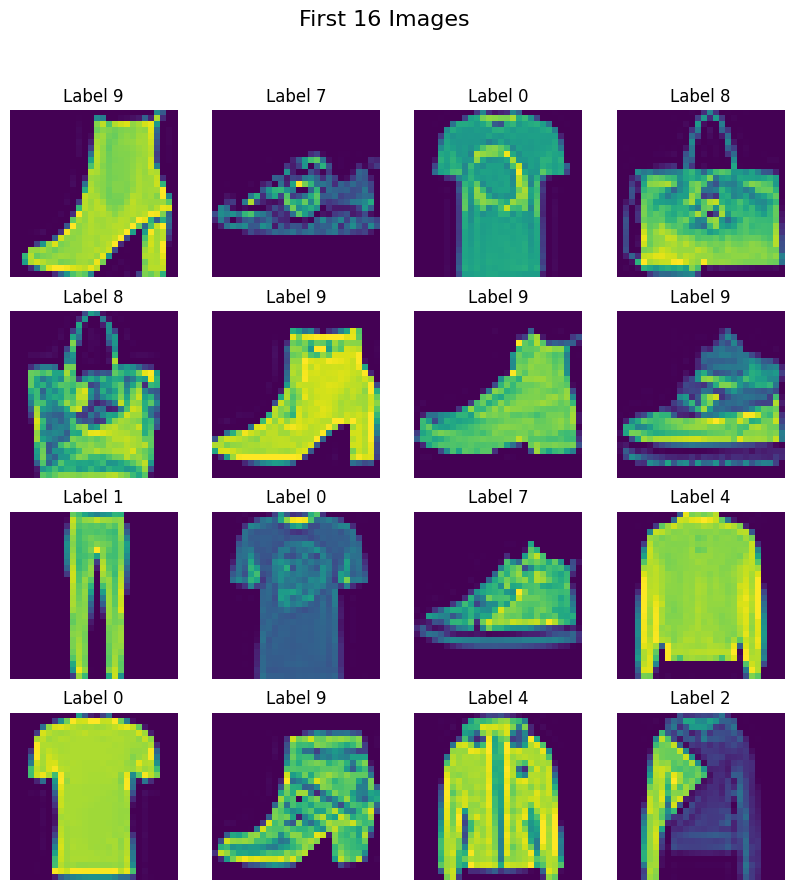

In [5]:
fig,axes= plt.subplots(4,4,figsize=(10,10))
fig.suptitle('First 16 Images', fontsize=16)

for i,ax in enumerate(axes.flat):
    img= df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    
    ax.set_title(f'Label {df.iloc[i,0]}')

In [6]:
df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='str', length=785)

In [8]:
len(df.columns)

785

In [9]:
df['label']

0       9
1       7
2       0
3       8
4       8
       ..
5995    1
5996    5
5997    8
5998    4
5999    8
Name: label, Length: 6000, dtype: int64

In [11]:
df['label'].unique()

array([9, 7, 0, 8, 1, 4, 2, 6, 5, 3])

In [12]:
len(df['label'].unique())

10

# Train Test Split

In [15]:
X = df.drop('label', axis=1)
y = df['label']

In [18]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# scaling the features
X_train= X_train/255.0
X_test= X_test/255.0